In [1]:
using DrWatson

@quickactivate "Fission-Yeast-Rec8"

projectname()

"Fission-Yeast-Rec8"

In [2]:
using Distributions
using CairoMakie
using Random
using Distributed
using Optimization
using OptimizationOptimJL
using LinearAlgebra
using DataFrames
using XLSX
using Statistics
using Base.Iterators
using LogExpFunctions
using KernelDensity
using HighestDensityRegions
using LogDensityProblems
using ForwardDiff
using AdaptiveMCMC
using TransformVariables, TransformedLogDensities, LogDensityProblems, LogDensityProblemsAD,
    DynamicHMC, DynamicHMC.Diagnostics

import ForwardDiff: hessian

using OptimizationNLopt

using ColorSchemes, Colors
using Dates

include(srcdir("FissionYeast.jl"));

┌ Warning: Replacing docs for `SciMLBase.sol :: Union{Tuple, Tuple{D}, Tuple{S}, Tuple{N}, Tuple{T}} where {T, N, S, D}` in module `SciMLBase`
└ @ Base.Docs docs/Docs.jl:240


In [9]:
save_figs = false  # save figures
run_evolution = false # run agent-based evolutionary simulations
save_data_outputs = false # save simulation output datafiles

false

In [10]:
posterior_data = load(datadir("exp_pro/PQInference/posterior_hill_Final.jld2"))

posterior = posterior_data["all_posterior"]

p_map_orig =  posterior_data["map"]

kp = posterior_data["ratio"]

# p_map = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = p_map_orig[:κq], Δq = p_map_orig[:Δq])

3.60141956626879

In [16]:
p_map_orig

(f = 0.8027641261375005, hm = 1.6951516820841541, am = 1.5544089543154018, κm = 0.7719829093343913, Δm = 0.9994617472328807, hq = 1.6155652110062733, aq = 6.105708950334785, κq = 0.8849584798764843, Δq = 0.40584439734370054)

In [11]:
expData = load(datadir("exp_pro/PQInference/ExpDataFinal_Final.jld2"))

PmData = expData["PmData"];
QData = expData["QData"];

cap = ceil(QData[end,:AU])

15.0

In [12]:
reproductive_fitness(rm,rp,p) = 2*(1-p[:f])*(q(rm,p) +  q(rp,p)) + 4*p[:f]*Pm(rm,rp,p)

reproductive_fitness(r,p) = reproductive_fitness(r[1],r[2],p)

reproductive_fitness_sym(r,p) = reproductive_fitness(r,r,p)

####################

reproductive_fitness_opt(r,p) = -reproductive_fitness(r,p)
reproductive_fitness_opt_1d(r,p) = -reproductive_fitness_sym(r[1],p)

####################

optf = OptimizationFunction(reproductive_fitness_opt, Optimization.AutoForwardDiff())

(::OptimizationFunction{true, AutoForwardDiff{nothing, Nothing}, typeof(reproductive_fitness_opt), Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME), Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing}) (generic function with 1 method)

In [17]:
σ = 0.025
additive_mutation_distribution = Normal(0.,σ)

max_au_correspondence = cap

max_pop_size = 10000

n_mitosis_rounds = 1

p_sister = 0.

PP = PopulationParameters(max_pop_size,Int(max_pop_size/2),n_mitosis_rounds,p_sister,additive_mutation_distribution,max_au_correspondence);

In [18]:
N_gen = 20000
initial_spore = Spore(1.,1.)

Spore(1.0, 1.0)

In [22]:
p_map = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = p_map_orig[:κq], Δq = p_map_orig[:Δq])

(f = 0.9, hm = 1.6951516820841541, am = 1.5544089543154018, κm = 0.7719829093343913, Δm = 0.9994617472328807, hq = 1.6155652110062733, aq = 6.105708950334785, κq = 0.8849584798764843, Δq = 0.40584439734370054)

In [23]:
PmData = expData["PmData"];
QData = expData["QData"];

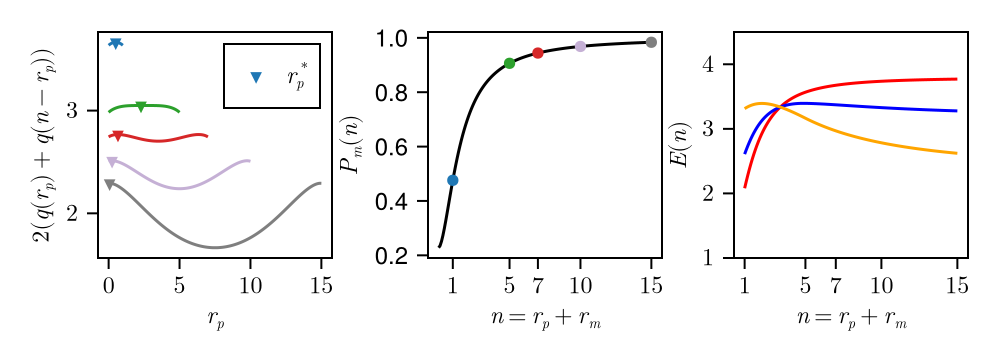

In [24]:
fig = Figure(size = (500,180), fontsize = 12.)

q_sym(r,n) = q(r,p_map) + q(n-r,p_map)

ax = Axis(fig[1,1], xlabel = L"r_p",ylabel = L"2(q(r_p) + q(n - r_p))",xgridvisible = false,ygridvisible = false)
ax1 = Axis(fig[1,2], xlabel = L"n = r_p + r_m",ylabel = L"P_m(n)",xgridvisible = false,ygridvisible = false)
ax2 = Axis(fig[1,3], xlabel = L"n = r_p + r_m",ylabel = L"E(n)",xgridvisible = false,ygridvisible = false)

n_sol = []
n_sol_max = []

choice_n = [1,5,7,10,15]

ms = 8.

for n in choice_n

    lines!(ax, 0:0.1:n,2*q_sym.(0:0.1:n,n),color = ColorSchemes.tab20[n])

    q_sym_opt(x,p) = -q_sym(x[1],n)

    q_sym_optf = OptimizationFunction(q_sym_opt, Optimization.AutoForwardDiff())
    
    u0 = [n/3]
    p0 = [0.]
    
    prob_1d = OptimizationProblem(q_sym_optf, u0, p0,lb = [0.],ub = [n])
    
    sol_1d = solve(prob_1d,BFGS())

    push!(n_sol,sol_1d)
    push!(n_sol_max,-q_sym_opt(sol_1d.u,p0))

    opt_q = min(sol_1d.u[1],n-sol_1d.u[1])

    if n == choice_n[1]
        scatter!(ax,[opt_q],[-2*q_sym_opt(opt_q,p0)],color = ColorSchemes.tab20[n],markersize = ms,marker = :dtriangle,label = L"r_p^*")
    else
        scatter!(ax,[opt_q],[-2*q_sym_opt(opt_q,p0)],color = ColorSchemes.tab20[n],markersize = ms,marker = :dtriangle)
    end
    
end 

CairoMakie.lines!(ax1,0:0.1:choice_n[end],[Pm(n,p_map) for n in 0:0.1:choice_n[end]],color = :black)
CairoMakie.scatter!(ax1,choice_n,[Pm(n,p_map) for n in choice_n],color = [ColorSchemes.tab20[n] for n in choice_n],markersize = ms)

n_sol = []
n_sol_max = []

tr = 1:0.1:cap

for n in tr 

    q_sym_opt(x,p) = -q_sym(x[1],n)

    q_sym_optf = OptimizationFunction(q_sym_opt, Optimization.AutoForwardDiff())
    
    u0 = [n/3]
    p0 = [0.]
    
    prob_1d = OptimizationProblem(q_sym_optf, u0, p0,lb = [0.],ub = [n])
    
    sol_1d = solve(prob_1d,BFGS())

    push!(n_sol,sol_1d)
    push!(n_sol_max,-q_sym_opt(sol_1d.u,p0))
end 

CairoMakie.lines!(ax2,tr,[4 * p_map[:f] * Pm(n,p_map) + 2*(1-p_map[:f]) *n_sol_max[i] for (i,n) in enumerate(tr)],color = :red,label = L"f = 0.9")

f = 0.6

CairoMakie.lines!(ax2,tr,[4 * f * Pm(n,p_map) + 2*(1-f) *n_sol_max[i] for (i,n) in enumerate(tr)],color = :blue,label = L"f = 0.6")

f = 0.2

CairoMakie.lines!(ax2,tr,[4 * f * Pm(n,p_map) + 2*(1-f) *n_sol_max[i] for (i,n) in enumerate(tr)],color = :orange,label = L"f = 0.2")

ax.xticks = ([0,5,10,15],[L"0",L"5",L"10",L"15"])
ax1.xticks = (choice_n,[L"1",L"5",L"7",L"10",L"15"])
ax2.xticks = (choice_n,[L"1",L"5",L"7",L"10",L"15"])

ylims!(ax2,1,4.5)

ax2.yticks = ([1,2,3,4],[L"1",L"2",L"3",L"4"])

ax.yticks = ([1,2,3,4],[L"1",L"2",L"3",L"4"])

axislegend(ax)

rowgap!(fig.layout,Relative(0.01))
colgap!(fig.layout,Relative(0.01))

fig

In [138]:
sc_factor = 0.1 

p_map = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = p_map_orig[:κq], Δq = p_map_orig[:Δq])

(f = 0.9, hm = 1.6951516820841541, am = 1.5544089543154018, κm = 0.7719829093343913, Δm = 0.9994617472328807, hq = 1.6155652110062733, aq = 6.105708950334785, κq = 0.8849584798764843, Δq = 0.40584439734370054)

In [66]:
nc = 4.6

4.6

In [184]:
#nstar setup 

optf_2d = OptimizationFunction(reproductive_fitness_opt, Optimization.AutoForwardDiff())

u0_2d = [cap/2,cap/2]

prob_2d = OptimizationProblem(optf_2d, u0_2d, p_map,lb = [0.,0.], ub = [cap,cap])

### nc setup

tr = 1:0.1:cap

### perturbation setup

κq_range = LinRange(0.5*p_map_orig[:κq],1,100)

κm_range = LinRange(0.5*p_map_orig[:κm],1.,100)

### κq analysis

κq_nc = []
κq_nstar = []

for κq in κq_range

    p_test = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = κq, Δq = p_map_orig[:Δq])

    prob_2d = remake(prob_2d, p = p_test)

    sol_2d = solve(prob_2d,IPNewton())

    q_sym(r,n) = q(r,p_test) + q(n-r,p_test)

    push!(κq_nc,nc)
    push!(κq_nstar,[maximum(sol_2d.u),minimum(sol_2d.u)])
end

### κm analysis

κm_nstar = []
κm_nc = []

for κm in κm_range

    p_test = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = κm , Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = p_map_orig[:κq], Δq = p_map_orig[:Δq])

    prob_2d = remake(prob_2d, p = p_test)

    sol_2d = solve(prob_2d,IPNewton())

    nstar = sum(sol_2d)

    push!(κm_nc,nc)
    push!(κm_nstar,[maximum(sol_2d.u),minimum(sol_2d.u)])
end


In [185]:
#nstar setup 

optf_2d = OptimizationFunction(reproductive_fitness_opt, Optimization.AutoForwardDiff())

u0_2d = [cap/2,cap/2]

prob_2d = OptimizationProblem(optf_2d, u0_2d, p_map,lb = [0.,0.], ub = [cap,cap])

### nc setup

tr = 1:0.1:cap

### perturbation setup

Δq_range = LinRange(0.5*p_map_orig[:Δq],1.,100)

Δm_range = LinRange(0.5*p_map_orig[:Δm],1.,100)

### κq analysis

Δq_nc = []
Δq_nstar = []

for Δq in Δq_range

    p_test = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = p_map_orig[:κq], Δq = Δq)

    prob_2d = remake(prob_2d, p = p_test)

    sol_2d = solve(prob_2d,IPNewton())

    q_sym(r,n) = q(r,p_test) + q(n-r,p_test)

    push!(Δq_nc,nc)
    push!(Δq_nstar,[maximum(sol_2d.u),minimum(sol_2d.u)])
end

### κm analysis

Δm_nstar = []
Δm_nc = []

for Δm in Δm_range

    p_test = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm] , Δm = Δm, hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = p_map_orig[:κq], Δq = p_map_orig[:Δq])

    prob_2d = remake(prob_2d, p = p_test)

    sol_2d = solve(prob_2d,IPNewton())

    nstar = sum(sol_2d)

    push!(Δm_nc,nc)
    push!(Δm_nstar,[maximum(sol_2d.u),minimum(sol_2d.u)])
end

In [187]:
peturb = 0.5

p_test_dm1 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = (1-peturb)*p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq =  p_map_orig[:κq], Δq = p_map_orig[:Δq])
p_test_dm2 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = 1., hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq =  p_map_orig[:κq], Δq = p_map_orig[:Δq])

p_test_km1 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = (1-peturb)*p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq =  p_map_orig[:κq], Δq = p_map_orig[:Δq])
p_test_km2 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = 1., Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq =  p_map_orig[:κq], Δq = p_map_orig[:Δq])

p_test_dq1 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq =  p_map_orig[:κq], Δq = (1-peturb)*p_map_orig[:Δq])
p_test_dq2 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq =  p_map_orig[:κq], Δq = 1.)

p_test_kq1 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = (1-peturb)*p_map_orig[:κq], Δq = p_map_orig[:Δq])
p_test_kq2 = (f = 0.9, hm = p_map_orig[:hm], am = p_map_orig[:am], κm = p_map_orig[:κm], Δm = p_map_orig[:Δm], hq = p_map_orig[:hq], aq = p_map_orig[:aq], κq = 1., Δq = p_map_orig[:Δq])


(f = 0.9, hm = 1.6951516820841541, am = 1.5544089543154018, κm = 0.7719829093343913, Δm = 0.9994617472328807, hq = 1.6155652110062733, aq = 6.105708950334785, κq = 1.0, Δq = 0.40584439734370054)

In [226]:
fig = Figure(size = (500,320), fontsize = 12.)

############################

ax1 = Axis(fig[1,1], xlabel = L"n = r_p + r_m",ylabel = L"E(n)",xgridvisible = false,ygridvisible = false,title = L"\Delta_m")
ax2 = Axis(fig[1,2], xlabel = L"n = r_p + r_m",ylabel = L"E(n)",xgridvisible = false,ygridvisible = false,title = L"\kappa_m")
ax3 = Axis(fig[1,3], xlabel = L"n = r_p + r_m",ylabel = L"E(n)",xgridvisible = false,ygridvisible = false,title = L"\Delta_q")
ax4 = Axis(fig[1,4], xlabel = L"n = r_p + r_m",ylabel = L"E(n)",xgridvisible = false,ygridvisible = false,title = L"\kappa_q")

ax_list = [ax1,ax1,ax2,ax2,ax3,ax3,ax4,ax4]

color_list = [:blue,:orange,:blue,:orange,:blue,:orange,:blue,:orange]

tr = 1:0.1:cap

data = []

for (i,p_set) in enumerate([p_test_dm1,p_test_dm2,p_test_km1,p_test_km2,p_test_dq1,p_test_dq2,p_test_kq1,p_test_kq2])

    n_sol = []
    n_sol_max = []

    q_sym(r,n) = q(r,p_set) + q(n-r,p_set)

    for n in tr 

        q_sym_opt(x,p) = -q_sym(x[1],n)

        q_sym_optf = OptimizationFunction(q_sym_opt, Optimization.AutoForwardDiff())
        
        u0 = [n/3]
        p0 = [0.]
        
        prob_1d = OptimizationProblem(q_sym_optf, u0, p0,lb = [0.],ub = [n])
        
        sol_1d = solve(prob_1d,BFGS())

        push!(n_sol,sol_1d)
        push!(n_sol_max,-q_sym_opt(sol_1d.u,p0))
    end 

    CairoMakie.lines!(ax_list[i],tr,[4 * p_set[:f] * Pm(n,p_set) + 2*(1-p_set[:f]) *n_sol_max[i] for (i,n) in enumerate(tr)],label = labels[i])

    push!(data,[4 * p_set[:f] * Pm(n,p_set) + 2*(1-p_set[:f]) *n_sol_max[i] for (i,n) in enumerate(tr)])

    ylims!(ax_list[i],1,4.5)
    xlims!(ax_list[i],0,cap)

    ax_list[i].yticks = ([1,2,3,4],[L"1",L"2",L"3",L"4"])
    ax_list[i].xticks = ([0,5,10,15],[L"0",L"5",L"10",L"15"])

end

n_sol = []
n_sol_max = []

tr = 1:0.1:cap

q_sym(r,n) = q(r,p_map) + q(n-r,p_map)

for n in tr 

    q_sym_opt(x,p) = -q_sym(x[1],n)

    q_sym_optf = OptimizationFunction(q_sym_opt, Optimization.AutoForwardDiff())
    
    u0 = [n/3]
    p0 = [0.]
    
    prob_1d = OptimizationProblem(q_sym_optf, u0, p0,lb = [0.],ub = [n])
    
    sol_1d = solve(prob_1d,BFGS())

    push!(n_sol,sol_1d)
    push!(n_sol_max,-q_sym_opt(sol_1d.u,p0))
end 

for ax in [ax1,ax2,ax3,ax4]
    CairoMakie.lines!(ax,tr,[4 * p_map[:f] * Pm(n,p_map) + 2*(1-p_map[:f]) *n_sol_max[i] for (i,n) in enumerate(tr)],color = :red)
    ax.xticks = ([0,5,10,15],[L"0",L"5",L"10",L"15"])

end

rowgap!(fig.layout,Relative(0.01))
colgap!(fig.layout,Relative(0.01))


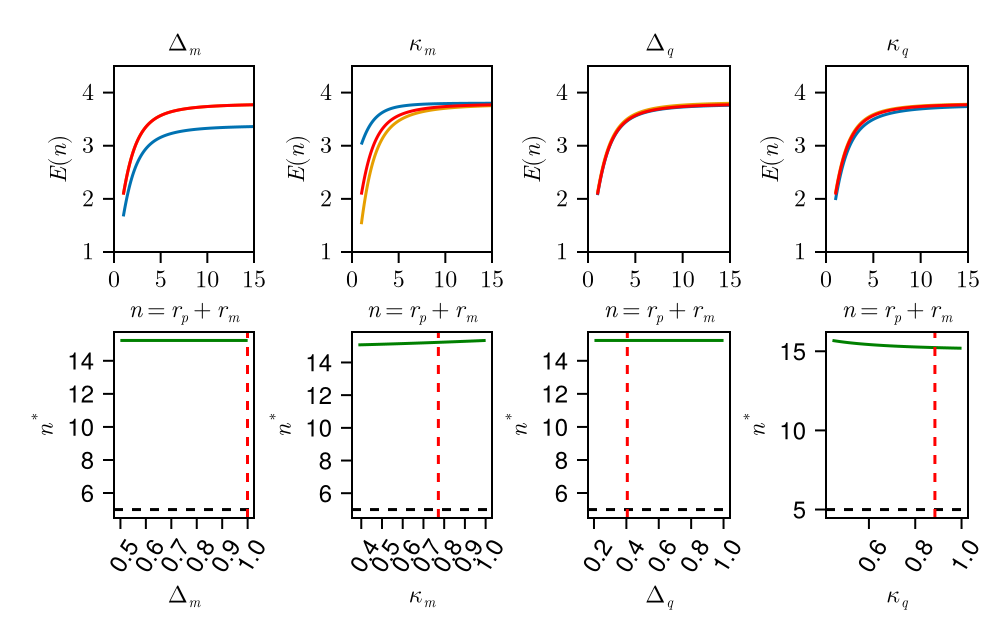

In [227]:
ax1 = Axis(fig[2,2], xlabel = L"\kappa_m",ylabel = L"n^*",xgridvisible = false,ygridvisible = false)
ax2 = Axis(fig[2,4], xlabel = L"\kappa_q",ylabel = L"n^*",xgridvisible = false,ygridvisible = false)
ax3 = Axis(fig[2,1], xlabel = L"\Delta_m",ylabel = L"n^*",xgridvisible = false,ygridvisible = false)
ax4 = Axis(fig[2,3], xlabel = L"\Delta_q",ylabel = L"n^*",xgridvisible = false,ygridvisible = false)

lines!(ax1,κm_range,sum.(κm_nstar),color = :green)
# lines!(ax1,κm_range,first.(κm_nstar),color = :blue)
# lines!(ax1,κm_range,last.(κm_nstar),color = :orange)

hlines!(ax1,nc,linestyle = :dash,color = :black)
vlines!(ax1,p_map_orig[:κm],linestyle = :dash,color = :red)

lines!(ax2,κq_range,sum.(κq_nstar),color = :green)
# lines!(ax2,κq_range,first.(κq_nstar),color = :blue)
# lines!(ax2,κq_range,last.(κq_nstar),color = :orange)

hlines!(ax2,nc,linestyle = :dash,color = :black)
vlines!(ax2,p_map_orig[:κq],linestyle = :dash,color = :red)


lines!(ax3,Δm_range,sum.(Δm_nstar),color = :green)
# lines!(ax1,κm_range,first.(κm_nstar),color = :blue)
# lines!(ax1,κm_range,last.(κm_nstar),color = :orange)

hlines!(ax3,nc,linestyle = :dash,color = :black)
vlines!(ax3,p_map_orig[:Δm],linestyle = :dash,color = :red)

lines!(ax4,Δq_range,sum.(Δq_nstar),color = :green)
# lines!(ax2,κq_range,first.(κq_nstar),color = :blue)
# lines!(ax2,κq_range,last.(κq_nstar),color = :orange)

hlines!(ax4,nc,linestyle = :dash,color = :black)
vlines!(ax4,p_map_orig[:Δq],linestyle = :dash,color = :red)

rowgap!(fig.layout,Relative(0.025))
colgap!(fig.layout,Relative(0.025))

# xlims!(ax1,κm_range[1],1.1*κm_range[end])
# xlims!(ax2,κq_range[1],κq_range[end])
# xlims!(ax3,Δm_range[1],Δm_range[end])
# xlims!(ax4,Δq_range[1],Δq_range[end])

ax1.xticklabelrotation = 45.
ax2.xticklabelrotation = 45.
ax3.xticklabelrotation = 45.
ax4.xticklabelrotation = 45.

save(plotsdir("DeltaKappaDependence.pdf"),fig)

fig

In [209]:
κm_range[end]

1.0